In [29]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [30]:
experiment = "smp_classic_cholesky_experiment"
result_dir = Path("results") / experiment
metrics = [
  "l1d_cache.overallMisses::total",
  "l1d_cache.overallHits::total",
  "l3_bus.transDist::UpgradeReq",
  "board.processor.cores0.core.cpi",
  "l3_bus.snoopTraffic"
  ]

In [31]:
def get_metric(metric:str, content:str):
    matcher = f"{metric}[ ]*([0-9].[0-9]*)" 
    metric_search = re.search(matcher, content, re.IGNORECASE)
    if metric_search:
        result = float(metric_search.group(1))
        return result
    

In [32]:
df_dict = {}

results = []

data_str = ""

for dir in result_dir.glob("*"):
  name = dir.name

  if(not dir.is_dir()):
    continue # we dont care about .out files


  # print(name)
  df_dict[name] = {}

  # open stat file
  statfile = result_dir/ name / "stats.txt"
  with open(statfile, "r") as stats:
    stats = stats.read()
    for metric in metrics:
      m = get_metric(metric, stats)
      # print(metric, m)
      df_dict[name][metric] = m


df_dict

{'16': {'l1d_cache.overallMisses::total': 28093.0,
  'l1d_cache.overallHits::total': 317694.0,
  'l3_bus.transDist::UpgradeReq': 14576.0,
  'board.processor.cores0.core.cpi': 3.547815,
  'l3_bus.snoopTraffic': 4403904.0},
 '2': {'l1d_cache.overallMisses::total': 6998.0,
  'l1d_cache.overallHits::total': 352400.0,
  'l3_bus.transDist::UpgradeReq': 2439.0,
  'board.processor.cores0.core.cpi': 3.48665,
  'l3_bus.snoopTraffic': 309376.0},
 '4': {'l1d_cache.overallMisses::total': 8134.0,
  'l1d_cache.overallHits::total': 249289.0,
  'l3_bus.transDist::UpgradeReq': 4372.0,
  'board.processor.cores0.core.cpi': 3.46248,
  'l3_bus.snoopTraffic': 854080.0},
 '8': {'l1d_cache.overallMisses::total': 14693.0,
  'l1d_cache.overallHits::total': 236798.0,
  'l3_bus.transDist::UpgradeReq': 7777.0,
  'board.processor.cores0.core.cpi': 3.498388,
  'l3_bus.snoopTraffic': 1977856.0}}

In [33]:
df = pd.DataFrame(df_dict)
df

,16,2,4,8
l1d_cache.overallMisses::total,2.809300e+04,6998.00000,8134.00000,1.469300e+04
l1d_cache.overallHits::total,3.176940e+05,352400.00000,249289.00000,2.367980e+05
l3_bus.transDist::UpgradeReq,1.457600e+04,2439.00000,4372.00000,7.777000e+03
board.processor.cores0.core.cpi,3.547815e+00,3.48665,3.46248,3.498388e+00
l3_bus.snoopTraffic,4.403904e+06,309376.00000,854080.00000,1.977856e+06


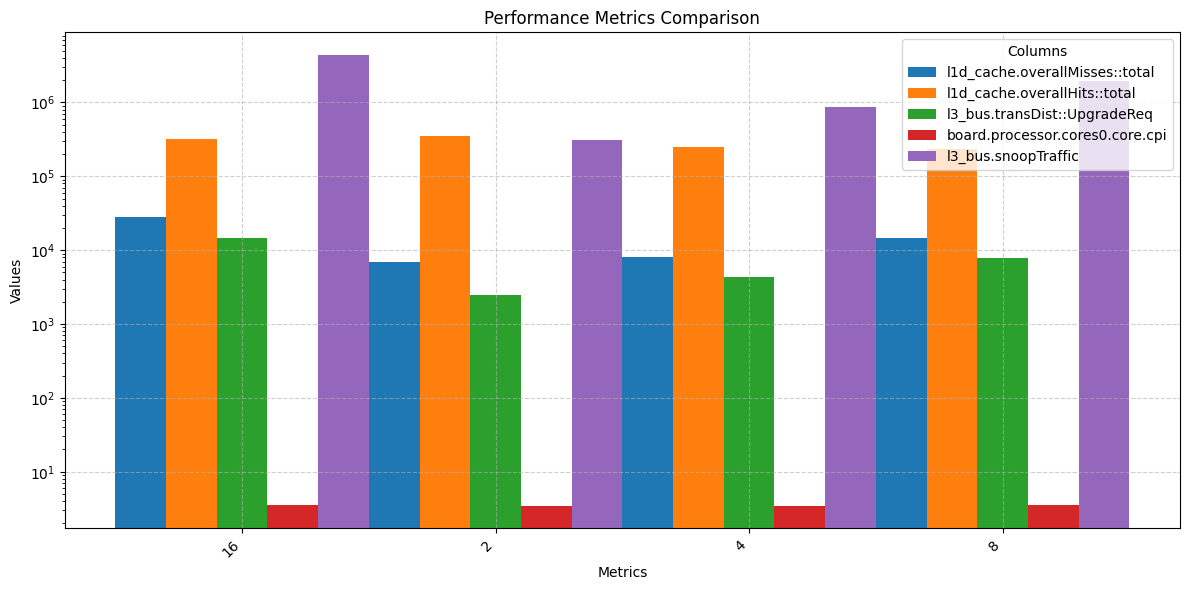

In [36]:
import matplotlib.pyplot as plt

# Plotting
plt.figure(figsize=(12, 6))
df=df.T
# Get the metrics (index) and columns
metrics = df.index
columns = df.columns

# Set the bar width and positions
bar_width = 0.2
x_pos = np.arange(len(metrics))

# Create bars for each column
for i, col in enumerate(columns):
    plt.bar(
        x_pos + i * bar_width,
        df[col],
        width=bar_width,
        label=f"{col}"
    )

# Customize the plot
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.yscale("log")
plt.title('Performance Metrics Comparison')
plt.xticks(x_pos + bar_width * (len(columns) / 2 - 0.5), metrics, rotation=45, ha='right')
plt.legend(title='Columns')
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
path = Path("graphs") / "cholesky" / "comparison.png"
plt.savefig(path)
plt.show()


In [38]:
datastr = df_dict
datastr

{'16': {'l1d_cache.overallMisses::total': 28093.0,
  'l1d_cache.overallHits::total': 317694.0,
  'l3_bus.transDist::UpgradeReq': 14576.0,
  'board.processor.cores0.core.cpi': 3.547815,
  'l3_bus.snoopTraffic': 4403904.0},
 '2': {'l1d_cache.overallMisses::total': 6998.0,
  'l1d_cache.overallHits::total': 352400.0,
  'l3_bus.transDist::UpgradeReq': 2439.0,
  'board.processor.cores0.core.cpi': 3.48665,
  'l3_bus.snoopTraffic': 309376.0},
 '4': {'l1d_cache.overallMisses::total': 8134.0,
  'l1d_cache.overallHits::total': 249289.0,
  'l3_bus.transDist::UpgradeReq': 4372.0,
  'board.processor.cores0.core.cpi': 3.46248,
  'l3_bus.snoopTraffic': 854080.0},
 '8': {'l1d_cache.overallMisses::total': 14693.0,
  'l1d_cache.overallHits::total': 236798.0,
  'l3_bus.transDist::UpgradeReq': 7777.0,
  'board.processor.cores0.core.cpi': 3.498388,
  'l3_bus.snoopTraffic': 1977856.0}}